In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [3]:
df=pd.read_csv('heart.csv')

In [4]:
print("Shape:",df.shape)
print(df.head())
print(df.info())
print(df.describe())

Shape: (1000, 14)
   patient_id  age  gender  glucose_mg_dl  cholesterol_mg_dl  systolic_bp  \
0           1   32    Male            101                235          152   
1           2   31    Male            124                191          134   
2           3   45    Male             57                141          114   
3           4   75  Female             69                268          120   
4           5   53    Male            107                163          131   

   diastolic_bp   bmi  heart_rate smoking alcohol_consumption  \
0            79  28.5          73      No                 Yes   
1            77  33.9          71      No                 Yes   
2            71  27.2          79     Yes                 Yes   
3            82  21.5          61     Yes                 Yes   
4            75  23.3          73     Yes                  No   

  physical_activity family_history disease  
0               Low            Yes     Yes  
1               Low            Yes    

In [5]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
patient_id             0
age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           0
bmi                    0
heart_rate             0
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64


In [6]:
print("\nDuplicates:",df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicates: 0


In [7]:
le=LabelEncoder()

for col in df.columns:
    if df[col].dtype=='object':
        df[col]=le.fit_transform(df[col])

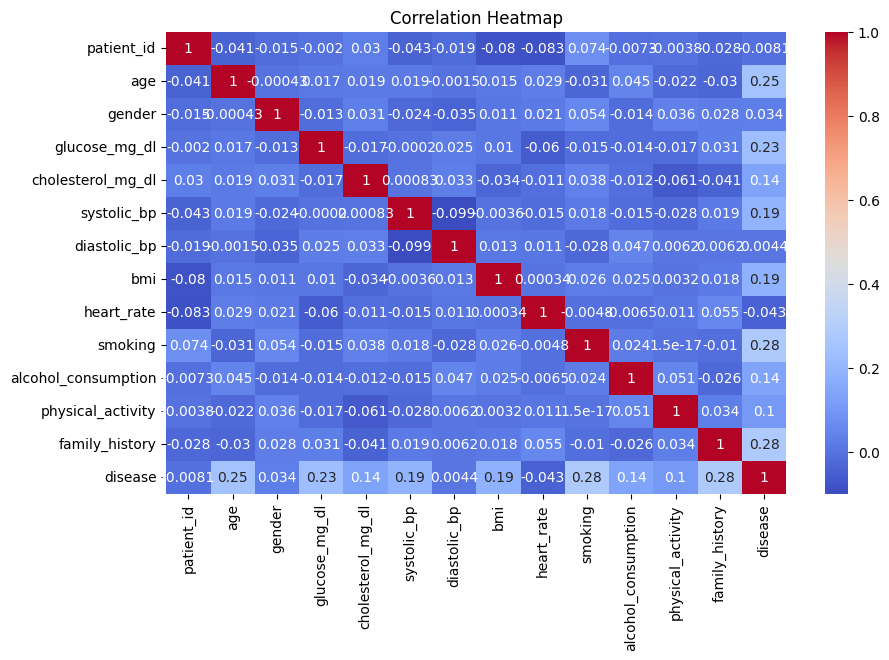

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [9]:
X=df.drop('disease',axis=1)
y=df['disease']

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [11]:
lr=LogisticRegression(max_iter=1000)
rf=RandomForestClassifier(n_estimators=100,random_state=42)
knn=KNeighborsClassifier()

In [12]:
lr.fit(X_train,y_train)
rf.fit(X_train,y_train)
knn.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KNeighborsClassifier()

In [13]:
lr_pred=lr.predict(X_test)
rf_pred=rf.predict(X_test)
knn_pred=knn.predict(X_test)

In [14]:
results=pd.DataFrame({
    'Model':['Logistic Regression','Random Forest','KNN'],
    'Accuracy':[accuracy_score(y_test,lr_pred),accuracy_score(y_test,rf_pred),accuracy_score(y_test,knn_pred)],
    'Precision':[precision_score(y_test,lr_pred),precision_score(y_test,rf_pred),precision_score(y_test,knn_pred)],
    'Recall':[recall_score(y_test,lr_pred),recall_score(y_test,rf_pred),recall_score(y_test,knn_pred)],
    'F1 Score':[f1_score(y_test,lr_pred),f1_score(y_test,rf_pred),f1_score(y_test,knn_pred)]
})

In [15]:
print("\nModel Comparison Table")
print(results)


Model Comparison Table
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression      0.76   0.770115  0.705263  0.736264
1        Random Forest      0.89   0.876289  0.894737  0.885417
2                  KNN      0.63   0.615385  0.589474  0.602151


In [16]:
best_model=results.sort_values(by='Accuracy',ascending=False).iloc[0]['Model']
print("\nBest Model:",best_model)


Best Model: Random Forest


In [17]:
if best_model=='Logistic Regression':
    best_pred=lr_pred
elif best_model=='Random Forest':
    best_pred=rf_pred
else:
    best_pred=knn_pred

In [18]:
cm=confusion_matrix(y_test,best_pred)

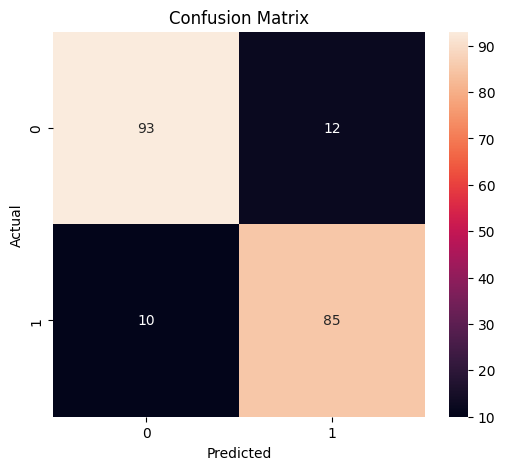

In [19]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [20]:
print("\nClassification Report")
print(classification_report(y_test,best_pred))


Classification Report
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       105
           1       0.88      0.89      0.89        95

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



In [21]:
feature_importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

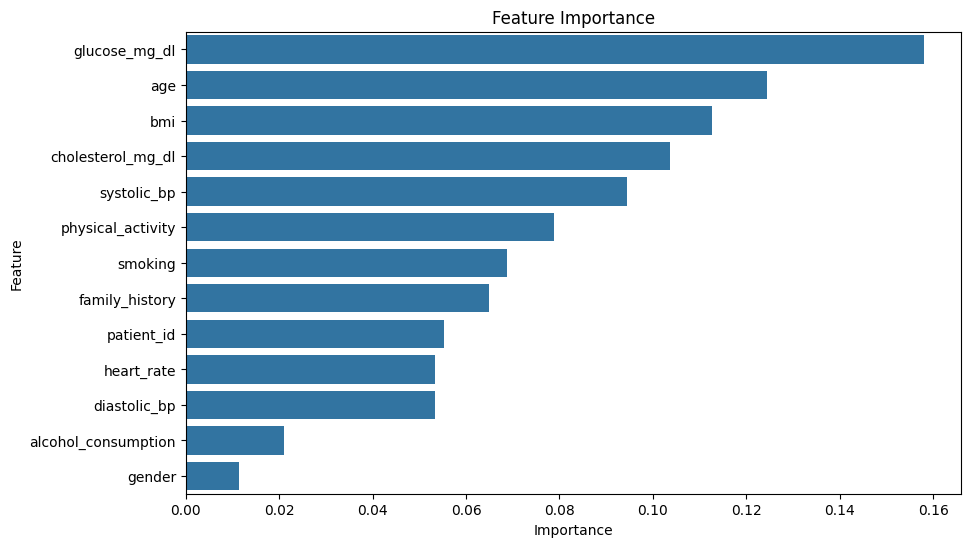

In [22]:
feature_importance=feature_importance.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance,x='Importance',y='Feature')
plt.title('Feature Importance')
plt.show()

In [23]:
print("\nTop Important Features")
print(feature_importance)


Top Important Features
                Feature  Importance
3         glucose_mg_dl    0.158001
1                   age    0.124481
7                   bmi    0.112544
4     cholesterol_mg_dl    0.103722
5           systolic_bp    0.094356
11    physical_activity    0.078859
9               smoking    0.068707
12       family_history    0.065008
0            patient_id    0.055224
8            heart_rate    0.053292
6          diastolic_bp    0.053284
10  alcohol_consumption    0.021037
2                gender    0.011484
